# XGBoost

This notebook is a complete, job-ready guide to XGBoost.

What you will learn:
- What XGBoost is and why it works so well
- Why we use XGBoost and when not to use it
- How it compares with Random Forest, linear models, SVM, and neural nets
- Full practical parameter guide for classification and regression
- Easy code examples for baseline modeling, tuning, and threshold selection
- Common mistakes, best practices, and interview-ready explanations

---

## Quick Definition

XGBoost (Extreme Gradient Boosting) is an optimized gradient boosting algorithm.

Instead of building many independent trees in parallel (like Random Forest), XGBoost builds trees **sequentially**:
- Each new tree learns to reduce previous errors.
- Final prediction is the sum of predictions from all trees (with learning rate scaling).

Because of this stage-wise error correction, XGBoost often gives top performance on tabular data.

## Why We Use XGBoost

XGBoost is popular because it usually gives strong accuracy on structured/tabular datasets with good speed and flexibility.

Main strengths:
- Excellent predictive performance on tabular data
- Handles nonlinear interactions automatically
- Supports missing values natively
- Strong regularization controls to reduce overfitting
- Works for classification, regression, and ranking
- Feature importance and SHAP compatibility
- Fast, optimized implementation (parallelized split finding)

In practical projects, XGBoost is often one of the first advanced models to test after a simple baseline.

## Why Not Other Models? (Model Choice Intuition)

No model is always best. You should compare based on data type, scale, interpretability, and latency.

### XGBoost vs Linear Models
- Linear models are easier to interpret and deploy.
- Choose linear models when relationships are mostly linear and interpretability is critical.
- XGBoost usually wins when feature interactions and nonlinearities matter.

### XGBoost vs Random Forest
- Random Forest is easier to tune and robust.
- XGBoost often gives better final performance due to sequential error correction.
- If your objective is max predictive quality on tabular data, XGBoost often outperforms RF.

### XGBoost vs CatBoost / LightGBM
- LightGBM is often faster on very large datasets.
- CatBoost handles categorical variables especially well out of the box.
- XGBoost is very stable, well-documented, and broadly used in interviews and production.

### XGBoost vs Neural Networks
- Neural nets dominate images/audio/text and extremely large representation-learning tasks.
- On medium tabular datasets, XGBoost is often simpler and stronger.

### XGBoost vs SVM / kNN
- SVM can work well on smaller datasets but may scale poorly.
- kNN is simple but expensive at inference and sensitive to scaling.
- XGBoost generally scales better and handles complex tabular relationships effectively.

## When XGBoost Is Not Ideal
- Very small datasets where simpler models already generalize well
- Strict need for transparent, coefficient-level interpretability
- Problems where sequence/image deep architectures are fundamentally better
- Very low-latency environments where a tiny linear model is preferred

## Theory: How XGBoost Works

### 1) Boosting Principle
XGBoost builds trees one by one.
At iteration $t$, it adds a new tree $f_t(x)$ to reduce errors from previous rounds.

For prediction after $T$ trees:

$$
\hat{y} = \sum_{t=1}^{T} \eta f_t(x)
$$

where $\eta$ is the learning rate.

### 2) Objective Function
XGBoost optimizes:

$$
\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_t \Omega(f_t)
$$

- $l(\cdot)$ is task loss (log loss, squared error, etc.)
- $\Omega(f)$ penalizes model complexity (regularization)

Typical regularization term:

$$
\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_j w_j^2
$$

- $T$: number of leaves
- $w_j$: leaf score
- $\gamma, \lambda$: regularization controls

### 3) Why It Generalizes Well
- Shrinkage (`learning_rate`) prevents aggressive updates.
- Tree constraints (`max_depth`, `min_child_weight`) limit complexity.
- Row and column subsampling (`subsample`, `colsample_*`) reduce variance.
- L1/L2 regularization (`reg_alpha`, `reg_lambda`) controls large leaf weights.

### 4) Missing Value Handling
XGBoost learns default split direction for missing values, so preprocessing is often simpler.

### 5) Early Stopping
Training can stop when validation metric stops improving for `early_stopping_rounds`.
This is one of the most important practical anti-overfitting tools.

## XGBoost Hyperparameters (Tailored 3-Type Framework)

Think of XGBoost tuning in 3 groups:

1. **Booster-specific hyperparameters** (XGBoost engine behavior)
2. **Tree-specific hyperparameters** (base tree learner complexity/splits)
3. **General hyperparameters** (common ML controls: objective, metric, reproducibility, compute)

---

### 1) Booster-Specific Hyperparameters (XGBoost-specific)

These define how boosting runs and which booster family is used.

- `booster`
  - What it does: chooses model family.
  - Options:
    - `"gbtree"` (default): boosted trees (most common)
    - `"gblinear"`: linear booster (acts like regularized linear model)
    - `"dart"`: tree boosting with dropout
  - Performance impact:
    - `gbtree`: strong nonlinear modeling; higher variance risk if too complex
    - `gblinear`: higher bias but fast and interpretable
    - `dart`: can reduce overfitting via dropout, but less stable and harder to tune

- `n_estimators`
  - What it does: number of boosting rounds/trees.
  - Options: positive integer (`100`, `300`, `1000`, ...).
  - Performance impact:
    - Too low -> underfitting (high bias)
    - Too high without enough regularization/early stopping -> overfitting (high variance)
    - Usually tuned jointly with `learning_rate`

- `learning_rate` (`eta`)
  - What it does: shrinkage factor per boosting step.
  - Options: float in `(0, 1]`, common `0.01` to `0.3`.
  - Performance impact:
    - Lower values reduce overfitting risk and improve generalization, but need more trees
    - Higher values train faster but can overfit/oscillate

- `tree_method`
  - What it does: split-finding algorithm.
  - Options (version/hardware dependent):
    - `"auto"`: library decides
    - `"exact"`: exact greedy split search (accurate, expensive)
    - `"approx"`: approximate split finding
    - `"hist"`: histogram-based (fast and common default in modern workflows)
    - `"gpu_hist"`: GPU histogram (older naming; newer API may use `device="cuda"` + `hist`)
  - Performance impact:
    - Primarily speed/memory tradeoff; model quality often similar when tuned
    - `hist`/GPU methods typically best for larger datasets

- `grow_policy`
  - What it does: how trees expand.
  - Options: `"depthwise"`, `"lossguide"`.
  - Performance impact:
    - `depthwise`: balanced growth; simpler behavior
    - `lossguide`: leaf-wise growth can improve accuracy on complex data, but may overfit if unconstrained

- `sampling_method`
  - What it does: row sampling strategy used with `subsample`.
  - Options: typically `"uniform"`; GPU may allow `"gradient_based"` in supported setups.
  - Performance impact:
    - `uniform`: stable standard behavior
    - `gradient_based`: focuses on impactful examples, can improve efficiency/performance in some cases

- `verbosity`
  - What it does: logging level.
  - Options: `0` silent, `1` warning, `2` info, `3` debug.
  - Performance impact: no direct model-quality impact; helps debugging training dynamics

---

### 2) Tree-Specific Hyperparameters (Base Learner Controls)

These directly control bias-variance and overfitting in boosted trees.

- `max_depth`
  - What it does: max depth per tree.
  - Options: integer >= 0 (`0`/very large effectively unlimited in some contexts).
  - Impact:
    - Lower -> higher bias, less overfitting
    - Higher -> lower bias, higher overfitting risk

- `min_child_weight`
  - What it does: minimum Hessian (second-order gradient sum) allowed in a child.
  - Options: non-negative float/int.
  - Impact:
    - Higher values make model more conservative -> less overfitting
    - Too high can underfit

- `gamma` (`min_split_loss`)
  - What it does: minimum loss reduction required to make a split.
  - Options: non-negative float.
  - Impact:
    - Higher gamma prunes weak splits -> lower variance
    - Too high prevents useful splits -> higher bias

- `subsample`
  - What it does: row sampling ratio per boosting round.
  - Options: float `(0, 1]`.
  - Impact:
    - Lower adds randomness and reduces overfitting
    - Too low can underfit

- `colsample_bytree`, `colsample_bylevel`, `colsample_bynode`
  - What they do: feature sampling at different granularity.
  - Options: each is float `(0, 1]`.
  - Impact:
    - Lower values reduce feature co-adaptation and variance
    - Too low can weaken trees (underfit)
  - Practical tip: start with `colsample_bytree` first; tune other two if needed

- `max_delta_step`
  - What it does: caps leaf weight update step size.
  - Options: non-negative float/int.
  - Impact:
    - Usually `0` for no cap
    - Useful for very imbalanced logistic problems; stabilizes updates and can improve generalization

---

### 3) General Hyperparameters (Common Across Many ML Workflows)

These are algorithm-agnostic controls used in many ML models.

- `reg_alpha` (L1 regularization)
  - What it does: sparsity-promoting penalty on leaf weights.
  - Options: non-negative float.
  - Impact:
    - Higher alpha can reduce overfitting and create sparse solutions
    - Too high can underfit

- `reg_lambda` (L2 regularization)
  - What it does: ridge-like penalty on leaf weights.
  - Options: non-negative float.
  - Impact:
    - Higher lambda smooths weights and reduces variance
    - Too high can underfit

- `scale_pos_weight` (binary imbalance)
  - What it does: increases weight of positive class gradients.
  - Options: positive float (common heuristic: negatives / positives).
  - Impact:
    - Improves minority sensitivity (recall/PR-AUC often improve)
    - Can reduce precision if set too aggressively

- `objective`
  - What it does: defines optimization target/loss.
  - Options (common):
    - Classification: `"binary:logistic"`, `"multi:softprob"`, `"multi:softmax"`
    - Regression: `"reg:squarederror"`, `"reg:absoluteerror"`, `"reg:pseudohubererror"`, `"reg:squaredlogerror"`
    - Ranking: `"rank:pairwise"`, `"rank:ndcg"`, `"rank:map"`
  - Impact: objective must match task and business setup; wrong objective causes systematic error

- `eval_metric`
  - What it does: metric monitored during training/validation.
  - Options (examples):
    - Classification: `"logloss"`, `"auc"`, `"aucpr"`, `"error"`
    - Regression: `"rmse"`, `"mae"`, `"rmsle"`
  - Impact: choose metric aligned with business goal (for imbalance, prefer `aucpr`, `f1`, recall-oriented views)

- `n_jobs`
  - What it does: CPU threads for training.
  - Options: integer; `-1` uses all cores.
  - Impact: speed/resource tradeoff only (not direct model quality).

- `random_state`
  - What it does: reproducibility of sampling and split behavior.
  - Impact: stable experimentation and fair model comparisons.

- `early_stopping_rounds` + `eval_set` (during fit)
  - What they do: stop training when validation metric fails to improve.
  - Impact: major overfitting control in daily production work.

---

## Expert Day-to-Day Tuning Techniques (AIML Practice)

1. **Two-stage search**: `RandomizedSearchCV` (coarse) -> `GridSearchCV` (local refinement).
2. **Early stopping first**: set high `n_estimators`, let early stopping pick effective rounds.
3. **Bias-variance ladder**: tune in order:
   1. `learning_rate` + `n_estimators`
   2. `max_depth`, `min_child_weight`, `gamma`
   3. `subsample`, `colsample_*`
   4. `reg_alpha`, `reg_lambda`
4. **Imbalance workflow**: tune `scale_pos_weight` + decision threshold (not threshold 0.5 by default).
5. **Version/hardware-aware setup**: prefer `tree_method="hist"` (and GPU path when available) for faster iteration.
6. **Metric-first development**: optimize business metric (PR-AUC/F1/recall/cost), not accuracy by default.

### Note
Some options are version/hardware dependent. Use the parameter checklist cell later in this notebook to verify exact support in your environment.

In [ ]:
# Imports for this notebook
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer, fetch_california_housing, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_recall_curve,
    roc_curve,
)

import matplotlib.pyplot as plt

# XGBoost import check
try:
    from xgboost import XGBClassifier, XGBRegressor
    xgb_available = True
except Exception as e:
    xgb_available = False
    print("XGBoost is not installed in this environment.")
    print("Install with: pip install xgboost")
    print("Import error:", e)

## Easy Code Example 1: Binary Classification

Dataset: Breast Cancer

Goals:
- Train baseline `XGBClassifier`
- Evaluate core metrics
- Inspect feature importance

In [10]:
if not xgb_available:
    raise ImportError("xgboost is required for this notebook. Install with: pip install xgboost")

# Load data
bc = load_breast_cancer()
X = pd.DataFrame(bc.data, columns=bc.feature_names)
y = pd.Series(bc.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline XGBoost classifier
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

xgb_clf.fit(X_train, y_train)

y_pred = xgb_clf.predict(X_test)
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

print("Classification Metrics")
print("-" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1        : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Feature importances
imp = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 Feature Importances")
print(imp.head(10))

Classification Metrics
----------------------------------------
Accuracy  : 0.9561
Precision : 0.9467
Recall    : 0.9861
F1        : 0.9660
ROC-AUC   : 0.9950

Confusion Matrix
[[38  4]
 [ 1 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Top 10 Feature Importances
worst perimeter         0.232428
mean concave points     0.169491
worst radius            0.109436
worst area              0.109055
worst concave points    0.088678
worst compactness       0.041151
mean area               0.023028
concavity error         0.019820
mean texture            0.018749
worst concavity         0.018600
dtype: float32


## Hyperparameter Tuning Strategy (Expert Workflow)

A practical workflow used in day-to-day AIML work:

1. Set a reasonable baseline (`tree_method="hist"`, reproducible seed, business metric).
2. Run **RandomizedSearchCV** for broad coverage of search space.
3. Refine with **GridSearchCV** around the randomized best region.
4. Train final model with **early stopping** on validation set.
5. For imbalance, tune probability threshold after model tuning.

In code below, we will explicitly report:
- `xgb_random.best_params_`
- `xgb_grid.best_params_`
- holdout and early-stopping based metrics

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Step 1: Coarse search (RandomizedSearchCV)
# -----------------------------
param_dist = {
    "booster": ["gbtree", "dart"],
    "n_estimators": [200, 300, 500, 800, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma": [0, 0.1, 0.2, 0.5, 1.0, 2.0],
    "subsample": [0.6, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "colsample_bylevel": [0.6, 0.8, 1.0],
    "colsample_bynode": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0, 5.0],
    "reg_lambda": [1, 2, 5, 10, 20],
    "scale_pos_weight": [1, 2, 5],
    "max_delta_step": [0, 1, 2, 5],
    "grow_policy": ["depthwise", "lossguide"],
    "sampling_method": ["uniform"],
    "verbosity": [0],
    "tree_method": ["hist"],
    "objective": ["binary:logistic"],
    "eval_metric": ["logloss"],
}

xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=35,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

xgb_random.fit(X_train, y_train)

print("RandomizedSearchCV best params:")
print(xgb_random.best_params_)
print(f"RandomizedSearchCV best CV F1: {xgb_random.best_score_:.4f}")

# -----------------------------
# Step 2: Fine search (GridSearchCV around best region)
# -----------------------------
best_random = xgb_random.best_params_

lr = best_random["learning_rate"]
md = best_random["max_depth"]
mcw = best_random["min_child_weight"]
gm = best_random["gamma"]

param_grid = {
    "booster": [best_random["booster"]],
    "n_estimators": sorted(set([
        max(100, int(best_random["n_estimators"] * 0.7)),
        best_random["n_estimators"],
        int(best_random["n_estimators"] * 1.3),
    ])),
    "learning_rate": sorted(set([max(0.005, lr * 0.5), lr, min(0.3, lr * 1.5)])),
    "max_depth": sorted(set([max(2, md - 1), md, md + 1])),
    "min_child_weight": sorted(set([max(1, int(mcw) - 1), int(mcw), int(mcw) + 1])),
    "gamma": sorted(set([max(0.0, gm - 0.1), gm, gm + 0.1])),
    "subsample": [best_random["subsample"]],
    "colsample_bytree": [best_random["colsample_bytree"]],
    "colsample_bylevel": [best_random["colsample_bylevel"]],
    "colsample_bynode": [best_random["colsample_bynode"]],
    "reg_alpha": [best_random["reg_alpha"]],
    "reg_lambda": [best_random["reg_lambda"]],
    "scale_pos_weight": [best_random["scale_pos_weight"]],
    "max_delta_step": [best_random["max_delta_step"]],
    "grow_policy": [best_random["grow_policy"]],
    "sampling_method": [best_random["sampling_method"]],
    "verbosity": [0],
    "tree_method": [best_random["tree_method"]],
    "objective": [best_random["objective"]],
    "eval_metric": [best_random["eval_metric"]],
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

xgb_grid.fit(X_train, y_train)

print("\nGridSearchCV best params (xgb_grid.best_params_):")
print(xgb_grid.best_params_)
print(f"GridSearchCV best CV F1: {xgb_grid.best_score_:.4f}")

# -----------------------------
# Step 3: Final fit with early stopping
# -----------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

final_params = dict(xgb_grid.best_params_)
final_params["n_jobs"] = -1
final_params["random_state"] = 42

best_xgb = XGBClassifier(**final_params)
try:
    # Works in many xgboost versions
    best_xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=50,
        verbose=False,
    )
except TypeError:
    # Fallback for versions where early_stopping_rounds is configured at init
    best_xgb = XGBClassifier(**final_params, early_stopping_rounds=50)
    best_xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print("\nHoldout metrics with final tuned model")
print("-" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_best):.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params:
{'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV F1: 0.9790
Test F1 with tuned model: 0.9660


## More Commonly Used Expert Tuning Techniques

Below are additional practical techniques frequently used in production AIML workflows:

1. **HalvingRandomSearchCV** (budget-efficient search)
   - Starts many configs with small resources, keeps best, increases resources progressively.
2. **Native XGBoost CV (`xgboost.cv`)**
   - Fast way to estimate best boosting rounds (`n_estimators`) with early stopping.
3. **Multi-metric model selection**
   - Track multiple metrics (for example `f1`, `roc_auc`, `average_precision`) and refit using the business-priority metric.

The next cell gives runnable templates and also prints one final `best_params` selected from all used searches.

In [ ]:
# Extra Technique 1: HalvingRandomSearchCV (if available in sklearn version)
halving_best_params = None
halving_best_score = None

try:
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
    from sklearn.model_selection import HalvingRandomSearchCV

    halving_param_dist = {
        "booster": ["gbtree", "dart"],
        "n_estimators": [200, 400, 800, 1200],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6, 8],
        "min_child_weight": [1, 3, 5, 7],
        "gamma": [0, 0.1, 0.5, 1.0],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.01, 0.1, 1.0],
        "reg_lambda": [1, 2, 5, 10],
        "scale_pos_weight": [1, 2, 5],
        "tree_method": ["hist"],
        "objective": ["binary:logistic"],
        "eval_metric": ["logloss"],
        "verbosity": [0],
    }

    xgb_halving = HalvingRandomSearchCV(
        estimator=XGBClassifier(random_state=42, n_jobs=-1),
        param_distributions=halving_param_dist,
        factor=3,
        resource="n_samples",
        max_resources="auto",
        min_resources="smallest",
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )

    xgb_halving.fit(X_train, y_train)
    halving_best_params = xgb_halving.best_params_
    halving_best_score = xgb_halving.best_score_

    print("HalvingRandomSearchCV best params:")
    print(halving_best_params)
    print(f"HalvingRandomSearchCV best CV F1: {halving_best_score:.4f}")
except Exception as e:
    print("HalvingRandomSearchCV not available in this environment.")
    print("Reason:", e)

# Extra Technique 2: Native XGBoost CV for best rounds (n_estimators) with early stopping
xgbcv_best_round = None
try:
    import xgboost as xgb

    dtrain = xgb.DMatrix(X_train, label=y_train)
    cv_params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "eta": 0.05,
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "gamma": 0.1,
        "lambda": 2.0,
        "alpha": 0.01,
        "tree_method": "hist",
    }

    cv_result = xgb.cv(
        params=cv_params,
        dtrain=dtrain,
        num_boost_round=2000,
        nfold=5,
        stratified=True,
        early_stopping_rounds=50,
        seed=42,
        verbose_eval=False,
    )

    xgbcv_best_round = int(len(cv_result))
    print(f"Native xgboost.cv best boosting rounds: {xgbcv_best_round}")
except Exception as e:
    print("Native xgboost.cv example skipped.")
    print("Reason:", e)

# Extra Technique 3: Multi-metric CV model selection (common in production)
multi_metric_scores = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

xgb_multi = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions={
        "n_estimators": [200, 400, 700, 1000],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6, 8],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.01, 0.1],
        "reg_lambda": [1, 2, 5, 10],
    },
    n_iter=20,
    scoring=multi_metric_scores,
    refit="pr_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
 )

xgb_multi.fit(X_train, y_train)
print("\nMulti-metric RandomizedSearchCV best params (refit='pr_auc'):")
print(xgb_multi.best_params_)
print(f"Best CV PR-AUC: {xgb_multi.best_score_:.4f}")

# One line: best params among all used searches (random, grid, halving-if-available, multi-metric)
best_params = max([("random", xgb_random.best_score_, xgb_random.best_params_), ("grid", xgb_grid.best_score_, xgb_grid.best_params_), ("multi", xgb_multi.best_score_, xgb_multi.best_params_)] + ([ ("halving", halving_best_score, halving_best_params) ] if halving_best_score is not None else []), key=lambda x: x[1])[2]
print("\nFinal selected best_params from used techniques:")
print(best_params)

if xgbcv_best_round is not None:
    print(f"Suggested n_estimators from native xgboost.cv: {xgbcv_best_round}")

## Easy Code Example 2: Regression

Dataset: California Housing

Goals:
- Train baseline `XGBRegressor`
- Evaluate MAE, RMSE, and $R^2$
- Inspect feature importance

In [12]:
housing = fetch_california_housing(as_frame=True)
X_reg = housing.data
y_reg = housing.target

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

xgb_reg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)
xgb_reg.fit(Xr_train, yr_train)

yr_pred = xgb_reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print("Regression Metrics")
print("-" * 40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

reg_imp = pd.Series(xgb_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)
print("\nTop Feature Importances")
print(reg_imp.head(10))

Regression Metrics
----------------------------------------
MAE  : 0.2925
RMSE : 0.4475
R2   : 0.8472

Top Feature Importances
MedInc        0.471828
AveOccup      0.132661
Longitude     0.108237
Latitude      0.106000
AveRooms      0.062831
HouseAge      0.062195
AveBedrms     0.032807
Population    0.023440
dtype: float32


## Visual Diagnostics

This section plots:
- Top feature importances
- ROC curve
- Precision-Recall curve

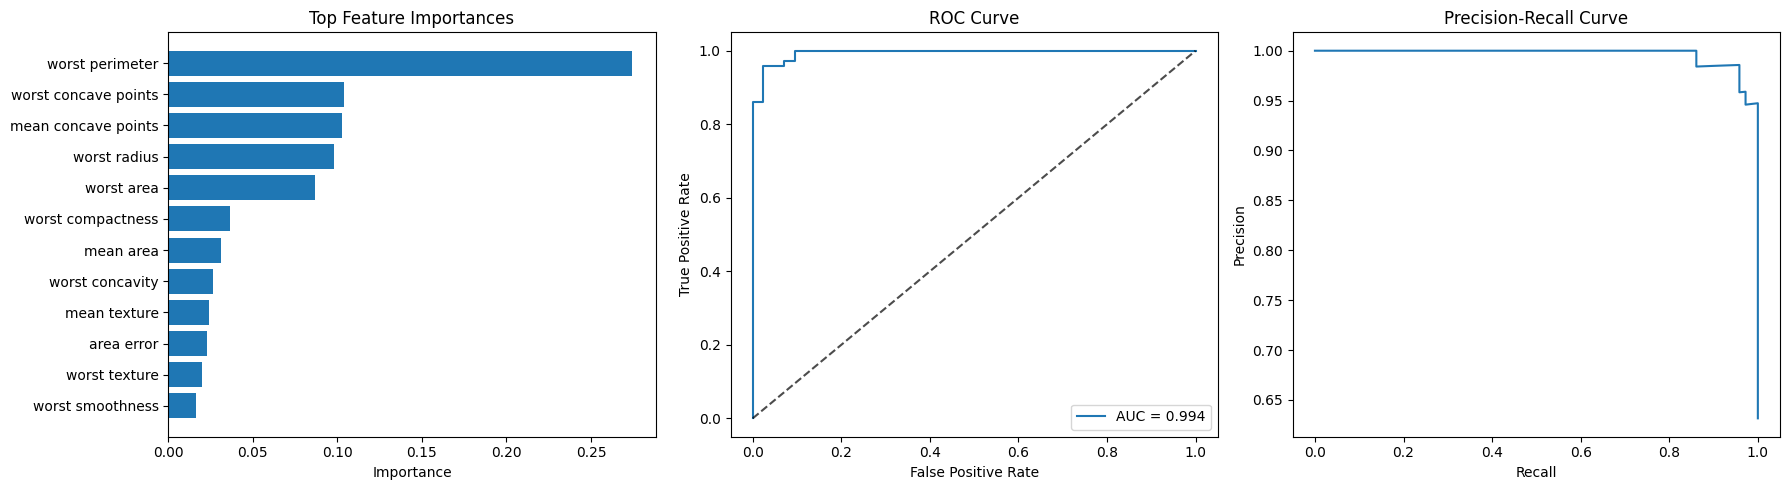

In [13]:
plot_model = best_xgb if 'best_xgb' in globals() else xgb_clf
plot_proba = plot_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Feature importance
feat_imp = pd.Series(plot_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
axes[0].barh(feat_imp.index[::-1], feat_imp.values[::-1])
axes[0].set_title("Top Feature Importances")
axes[0].set_xlabel("Importance")

# ROC
fpr, tpr, _ = roc_curve(y_test, plot_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, plot_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.7)
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, plot_proba)
axes[2].plot(recall, precision)
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.show()

## Imbalanced Classification + Threshold Tuning (Real-World Workflow)

Many production tasks (fraud, abuse, medical alerts) are imbalanced.

This section demonstrates:
- Using `scale_pos_weight`
- Why threshold 0.5 may fail
- How to tune threshold for better F1 or cost policy

Default threshold (0.5)
----------------------------------------
Precision: 0.8978
Recall   : 0.7410
F1       : 0.8119
ROC-AUC  : 0.9576

Best threshold by F1
threshold    0.630000
precision    0.937984
recall       0.728916
f1           0.820339
Name: 58, dtype: float64

Policy threshold (precision >= 0.85, max recall)
threshold    0.440000
precision    0.854167
recall       0.740964
f1           0.793548
Name: 39, dtype: float64


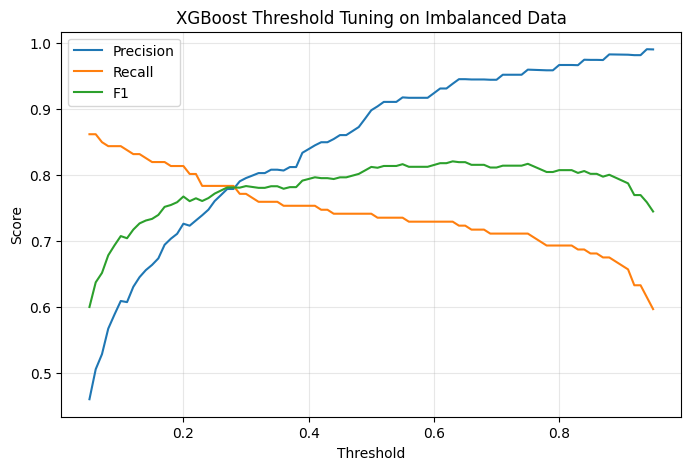

In [14]:
X_imb, y_imb = make_classification(
    n_samples=15000,
    n_features=30,
    n_informative=10,
    n_redundant=5,
    weights=[0.96, 0.04],
    class_sep=1.3,
    random_state=42,
)

X_imb = pd.DataFrame(X_imb)
y_imb = pd.Series(y_imb)

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=42, stratify=y_imb
)

neg = (yi_train == 0).sum()
pos = (yi_train == 1).sum()
spw = neg / pos

xgb_imb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)

xgb_imb.fit(Xi_train, yi_train)

proba_imb = xgb_imb.predict_proba(Xi_test)[:, 1]
default_pred = (proba_imb >= 0.5).astype(int)

print("Default threshold (0.5)")
print("-" * 40)
print(f"Precision: {precision_score(yi_test, default_pred):.4f}")
print(f"Recall   : {recall_score(yi_test, default_pred):.4f}")
print(f"F1       : {f1_score(yi_test, default_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(yi_test, proba_imb):.4f}")

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    pred_t = (proba_imb >= t).astype(int)
    p = precision_score(yi_test, pred_t, zero_division=0)
    r = recall_score(yi_test, pred_t, zero_division=0)
    f = f1_score(yi_test, pred_t, zero_division=0)
    rows.append((t, p, r, f))

th_df = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"])
best_f1_row = th_df.loc[th_df["f1"].idxmax()]
print("\nBest threshold by F1")
print(best_f1_row)

policy_df = th_df[th_df["precision"] >= 0.85]
if len(policy_df) > 0:
    policy_row = policy_df.loc[policy_df["recall"].idxmax()]
    print("\nPolicy threshold (precision >= 0.85, max recall)")
    print(policy_row)
else:
    print("\nNo threshold satisfied precision >= 0.85 on this split.")

plt.figure(figsize=(8, 5))
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Tuning on Imbalanced Data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Complete Parameter Checklist (Version-Aware)

XGBoost versions may differ.
Use the next cell to print the exact parameter list available in your environment.

In [15]:
if xgb_available:
    clf_params = XGBClassifier().get_params()
    reg_params = XGBRegressor().get_params()

    print("XGBClassifier parameters")
    print("-" * 40)
    for k in sorted(clf_params.keys()):
        print(k)

    print("\nXGBRegressor parameters")
    print("-" * 40)
    for k in sorted(reg_params.keys()):
        print(k)
else:
    print("XGBoost not available, parameter listing skipped.")

XGBClassifier parameters
----------------------------------------
base_score
booster
callbacks
colsample_bylevel
colsample_bynode
colsample_bytree
device
early_stopping_rounds
enable_categorical
eval_metric
feature_types
feature_weights
gamma
grow_policy
importance_type
interaction_constraints
learning_rate
max_bin
max_cat_threshold
max_cat_to_onehot
max_delta_step
max_depth
max_leaves
min_child_weight
missing
monotone_constraints
multi_strategy
n_estimators
n_jobs
num_parallel_tree
objective
random_state
reg_alpha
reg_lambda
sampling_method
scale_pos_weight
subsample
tree_method
validate_parameters
verbosity

XGBRegressor parameters
----------------------------------------
base_score
booster
callbacks
colsample_bylevel
colsample_bynode
colsample_bytree
device
early_stopping_rounds
enable_categorical
eval_metric
feature_types
feature_weights
gamma
grow_policy
importance_type
interaction_constraints
learning_rate
max_bin
max_cat_threshold
max_cat_to_onehot
max_delta_step
max_depth
max_l

## Common Mistakes and Best Practices

### Common Mistakes
- Setting very high `n_estimators` with high `learning_rate` (overfitting risk)
- Tuning only one parameter and ignoring interactions
- Using only accuracy on imbalanced data
- Ignoring early stopping
- Data leakage through preprocessing before split
- Treating feature importance as causal explanation

### Best Practices
- Start with small `learning_rate` (0.03 to 0.1)
- Increase `n_estimators` as `learning_rate` decreases
- Use CV and business-relevant metric (`f1`, `aucpr`, `rmse`, etc.)
- Use early stopping with validation set
- For imbalance, set `scale_pos_weight` and tune threshold
- Compare with at least one baseline (linear model or random forest)

### Practical Starter Baseline
- `learning_rate=0.05`
- `n_estimators=300 to 800`
- `max_depth=4 to 8`
- `subsample=0.8 to 1.0`
- `colsample_bytree=0.8 to 1.0`
- Add `reg_alpha/reg_lambda` if overfitting appears

## Interview and Job-Ready Answers (Short)

1. Why can XGBoost beat Random Forest?
- It boosts sequentially, correcting residual errors each round.

2. Why is `learning_rate` important?
- It controls step size; smaller values improve generalization but require more trees.

3. Why tune `max_depth` and `min_child_weight` together?
- They jointly control tree complexity and overfitting.

4. What does `subsample` and `colsample_bytree` do?
- They inject randomness to improve generalization and reduce variance.

5. Why use early stopping?
- It stops training when validation metric no longer improves.

6. How handle class imbalance in XGBoost?
- Use `scale_pos_weight`, proper metrics (PR-AUC/F1/recall), and threshold tuning.

7. Does XGBoost need feature scaling?
- Usually not required for tree booster.

8. What is a common overfitting pattern?
- Very deep trees + high learning rate + too many rounds without regularization.

9. Why can feature importance be misleading?
- Importance is association, not causality.

10. What metric should I optimize?
- The metric aligned with business cost (not always accuracy).

---

## Final Cheat Sheet

Use XGBoost when:
- Data is tabular
- You need high predictive performance
- You can invest in moderate hyperparameter tuning

Be careful when:
- Interpretability must be very simple
- Problem belongs to deep-learning-first domains (image/audio/text)
- You have strict tiny-model latency constraints

If you remember one line:

**XGBoost = regularized gradient boosting with strong accuracy, careful tuning, and excellent tabular performance.**

## Random Forest vs XGBoost (Same Split, Side-by-Side)

This section compares both models on the exact same train/test splits already used in this notebook.

Outputs:
- Classification comparison table (Accuracy, Precision, Recall, F1, ROC-AUC)
- Regression comparison table (MAE, RMSE, R2)
- Train time and predict time for quick speed intuition

In [16]:
import time
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Ensure required variables exist (from previous cells)
required_vars = ["X_train", "X_test", "y_train", "y_test", "Xr_train", "Xr_test", "yr_train", "yr_test"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(f"Run earlier code cells first. Missing: {missing_vars}")

# -----------------------------
# Classification comparison
# -----------------------------
rf_clf_cmp = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

xgb_clf_cmp = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

# Random Forest train + predict time
start = time.perf_counter()
rf_clf_cmp.fit(X_train, y_train)
rf_clf_train_time = time.perf_counter() - start

start = time.perf_counter()
rf_pred = rf_clf_cmp.predict(X_test)
rf_proba = rf_clf_cmp.predict_proba(X_test)[:, 1]
rf_clf_pred_time = time.perf_counter() - start

# XGBoost train + predict time
start = time.perf_counter()
xgb_clf_cmp.fit(X_train, y_train)
xgb_clf_train_time = time.perf_counter() - start

start = time.perf_counter()
xgb_pred = xgb_clf_cmp.predict(X_test)
xgb_proba = xgb_clf_cmp.predict_proba(X_test)[:, 1]
xgb_clf_pred_time = time.perf_counter() - start

clf_comparison = pd.DataFrame([
    {
        "model": "RandomForestClassifier",
        "accuracy": accuracy_score(y_test, rf_pred),
        "precision": precision_score(y_test, rf_pred),
        "recall": recall_score(y_test, rf_pred),
        "f1": f1_score(y_test, rf_pred),
        "roc_auc": roc_auc_score(y_test, rf_proba),
        "train_time_sec": rf_clf_train_time,
        "predict_time_sec": rf_clf_pred_time,
    },
    {
        "model": "XGBClassifier",
        "accuracy": accuracy_score(y_test, xgb_pred),
        "precision": precision_score(y_test, xgb_pred),
        "recall": recall_score(y_test, xgb_pred),
        "f1": f1_score(y_test, xgb_pred),
        "roc_auc": roc_auc_score(y_test, xgb_proba),
        "train_time_sec": xgb_clf_train_time,
        "predict_time_sec": xgb_clf_pred_time,
    },
]).sort_values(by="f1", ascending=False)

# -----------------------------
# Regression comparison
# -----------------------------
rf_reg_cmp = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
)

xgb_reg_cmp = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

start = time.perf_counter()
rf_reg_cmp.fit(Xr_train, yr_train)
rf_reg_train_time = time.perf_counter() - start

start = time.perf_counter()
rf_reg_pred = rf_reg_cmp.predict(Xr_test)
rf_reg_pred_time = time.perf_counter() - start

start = time.perf_counter()
xgb_reg_cmp.fit(Xr_train, yr_train)
xgb_reg_train_time = time.perf_counter() - start

start = time.perf_counter()
xgb_reg_pred = xgb_reg_cmp.predict(Xr_test)
xgb_reg_pred_time = time.perf_counter() - start

reg_comparison = pd.DataFrame([
    {
        "model": "RandomForestRegressor",
        "mae": mean_absolute_error(yr_test, rf_reg_pred),
        "rmse": np.sqrt(mean_squared_error(yr_test, rf_reg_pred)),
        "r2": r2_score(yr_test, rf_reg_pred),
        "train_time_sec": rf_reg_train_time,
        "predict_time_sec": rf_reg_pred_time,
    },
    {
        "model": "XGBRegressor",
        "mae": mean_absolute_error(yr_test, xgb_reg_pred),
        "rmse": np.sqrt(mean_squared_error(yr_test, xgb_reg_pred)),
        "r2": r2_score(yr_test, xgb_reg_pred),
        "train_time_sec": xgb_reg_train_time,
        "predict_time_sec": xgb_reg_pred_time,
    },
]).sort_values(by="r2", ascending=False)

print("Classification Comparison (same split)")
print("-" * 70)
print(clf_comparison.to_string(index=False))

print("\nRegression Comparison (same split)")
print("-" * 70)
print(reg_comparison.to_string(index=False))

Classification Comparison (same split)
----------------------------------------------------------------------
                 model  accuracy  precision   recall       f1  roc_auc  train_time_sec  predict_time_sec
         XGBClassifier   0.95614   0.946667 0.986111 0.965986 0.995701        0.399728          0.010518
RandomForestClassifier   0.95614   0.958904 0.972222 0.965517 0.993056        0.948355          0.262537

Regression Comparison (same split)
----------------------------------------------------------------------
                model      mae     rmse       r2  train_time_sec  predict_time_sec
         XGBRegressor 0.292465 0.447486 0.847190        0.935215          0.011629
RandomForestRegressor 0.325895 0.502199 0.807538        6.237469          0.194855
